In [1]:
import pandas as pd
import numpy as np
import ast
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
from pyro.infer import MCMC, NUTS
import pyro.distributions.constraints as constraints
from pyro.infer.autoguide import AutoMultivariateNormal, init_to_mean, AutoNormal, AutoGuide
from pyro.infer import SVI, Trace_ELBO, Predictive
import pyro.optim as optim
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
from tqdm import tqdm

## Preprocessing

In [2]:
raw_y = pd.read_csv('../RawData/서울교통공사_역별 일별 시간대별 승하차인원 정보_20231031.csv', encoding = 'cp949')
raw_y9 = pd.read_csv('../RawData/서울교통공사_9호선2_3단계 역별일별시간대별승하차인원_20231031.csv', encoding = 'cp949')

raw_y9['06시이전'] = raw_y9['03-04시간대'] + raw_y9['04-05시간대'] + raw_y9['05-06시간대']
raw_y9['24시이후'] = raw_y9['00-01시간대'] + raw_y9['01-02시간대'] + raw_y9['02-03시간대']
raw_y9.drop(columns = ['03-04시간대','04-05시간대', '05-06시간대','00-01시간대', '01-02시간대', '02-03시간대'], inplace = True)

raw_y9['승하차구분'] = raw_y9['승하차구분'].str.replace('순승차', '승차')
raw_y9['승하차구분'] = raw_y9['승하차구분'].str.replace('순하차', '하차')

raw_y = pd.concat([raw_y, raw_y9])
raw_y['역명'] = raw_y['역명'].apply(lambda x: x.split('(')[0])
raw_y['역명'] = raw_y['역명'].str.replace('서울역', '서울', regex=False)

raw_y = raw_y[raw_y['수송일자'].astype(str).str.startswith('2023-10')].copy() # Only October 2023 data
raw_y.reset_index(drop=True, inplace=True)

In [3]:
raw_y_sc = raw_y[raw_y['승하차구분'] == '승차']
raw_y_hc = raw_y[raw_y['승하차구분'] == '하차']

holidays = ['2023-10-01', '2023-10-02', '2023-10-03', '2023-10-07',
            '2023-10-08', '2023-10-09', '2023-10-14', '2023-10-15', '2023-10-21',
            '2023-10-22', '2023-10-28', '2023-10-29']
raw_y_wd_sc = raw_y_sc[~raw_y_sc['수송일자'].isin(holidays)]
raw_y_we_sc = raw_y_sc[raw_y_sc['수송일자'].isin(holidays)]
raw_y_wd_hc = raw_y_hc[~raw_y_hc['수송일자'].isin(holidays)]
raw_y_we_hc = raw_y_hc[raw_y_hc['수송일자'].isin(holidays)]

In [4]:
# Get standardized
time_columns = ['06시이전', '06-07시간대',
       '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
       '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대',
       '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대',    '24시이후']

daily_y_wd_sc = raw_y_wd_sc[['수송일자', '역명', '06시이전', '06-07시간대',
       '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
       '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대',
       '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '24시이후']].groupby(['수송일자', '역명']).sum().reset_index()

for k, v in daily_y_wd_sc.iterrows():
    vols = v[time_columns].tolist()
    daily_y_wd_sc.at[k, 'ridership'] = str(vols)
    '''
    vmax, vmin = v[time_columns].max(), v[time_columns].min()
    normed_vols = [((i - vmin) / (vmax - vmin)) for i in vols]
    daily_y_wd_sc.at[k, 'pattern'] = str(normed_vols)
    daily_y_wd_sc.at[k, 'max_ride'] = vmax
    daily_y_wd_sc.at[k, 'min_ride'] = vmin
    '''
daily_y_wd_sc = daily_y_wd_sc.drop(columns=time_columns)
daily_y_wd_sc.head(3)

,수송일자,역명,ridership
0,2023-10-04,가락시장,"[236, 535, 1538, 1560, 1047, 894, 810, 796, 86..."
1,2023-10-04,가산디지털단지,"[267, 418, 1065, 1176, 744, 624, 781, 951, 106..."
2,2023-10-04,강남,"[215, 619, 1785, 2835, 2061, 1873, 2126, 2663,..."


In [5]:
raw_ys = [raw_y_wd_sc, raw_y_we_sc, raw_y_wd_hc, raw_y_we_hc]
for ys in raw_ys:
    daily_ys = ys[['수송일자', '역명', '06시이전', '06-07시간대',
           '07-08시간대', '08-09시간대', '09-10시간대', '10-11시간대', '11-12시간대', '12-13시간대',
           '13-14시간대', '14-15시간대', '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대',
           '19-20시간대', '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '24시이후']].groupby(['수송일자', '역명']).sum().reset_index()

    for k, v in daily_ys.iterrows():
        vols = v[time_columns].tolist()
        daily_ys.at[k, 'ridership'] = str(vols)
        '''
        vmax, vmin = v[time_columns].max(), v[time_columns].min()
        normed_vols = [((i - vmin) / (vmax - vmin)) for i in vols]
        daily_ys.at[k, 'pattern'] = str(normed_vols)
        daily_ys.at[k, 'max_ride'] = vmax
        daily_ys.at[k, 'min_ride'] = vmin
        '''
    daily_ys = daily_ys.drop(columns=time_columns)
    daily_ys.to_csv('../Data/251215_daily_ridership_' + ('wd' if ys.equals(raw_y_wd_sc) or ys.equals(raw_y_wd_hc) else 'we') + ('_sc' if ys.equals(raw_y_wd_sc) or ys.equals(raw_y_we_sc) else '_hc') + '.csv', index=False)

## Read Data

In [2]:
daily_y_wd_hc = pd.read_csv('../Data/251215_daily_ridership_wd_hc.csv')

#########################################################Select date
date_test1 = [daily_y_wd_hc['수송일자'].unique()[0]]
date_test2 = daily_y_wd_hc['수송일자'].unique()[:7]
date_test3 = daily_y_wd_hc  ['수송일자'].unique()

date_tests = [date_test1, date_test2, date_test3]
test_number = 3
date_test = date_tests[test_number - 1]

In [3]:
df = pd.read_csv('../Data/train_wd_hc.csv', index_col = 0)

df.reset_index(drop=True, inplace = True)
df.drop(columns = ['id'], inplace= True)

df_x = df[['name', 'transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix']]

#daily_y_wd_sc.merge(df_x, left_on = '역명', right_on = 'name', right_index = True, how = 'left')
daily_y_wd_hc.rename(columns = {'역명': 'name', '수송일자': 'date'}, inplace = True)
df_date = df_x.merge(daily_y_wd_hc, on = 'name', how = 'left')

df_date[df_date['date'].isna()]

,name,transfer,outer,terminal,cbd,tfa_r,tfa_c,tfa_w,univ,pop,job,bus,buld_sum,rest,green,tfa_n,tfa_f,lumix,date,ridership


In [7]:
len(df_date['name'].unique())

226

In [4]:
# Get English name
df_enname = pd.read_csv('../Data/서울교통공사_역명다국어표기_20241101.csv', encoding = 'cp949')
df_enname['한글'] = df_enname['한글'].apply(lambda x: x.split('(')[0])
df_enname.drop_duplicates(subset=['한글'], inplace=True)
df_enname.rename(columns={'한글':'name', '영문':'en_name'}, inplace=True)
df_date = df_date.merge(df_enname[['name', 'en_name']], on = 'name', how='left', suffixes=('', '_y'))

df_date.loc[df_date['name'] == '미아사거리', 'en_name'] = 'MiaSageori'
df_date.loc[df_date['name'] == '뚝섬유원지', 'en_name'] = 'DduksomPark'
df_date.loc[df_date['name'] == '화랑대', 'en_name'] = 'Hwarangdae'
df_date.loc[df_date['name'] == '서울', 'en_name'] = 'SeoulStation'

df_date = df_date[['name', 'en_name', 'transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix', 'date', 'ridership']]
df_date[df_date['en_name'].isna()]

,name,en_name,transfer,outer,terminal,cbd,tfa_r,tfa_c,tfa_w,univ,...,job,bus,buld_sum,rest,green,tfa_n,tfa_f,lumix,date,ridership


In [5]:
df_x = df_date[['transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix']]
df_y = df_date[['ridership']]

df_x = df_x.apply(lambda col: col.fillna(col.min()), axis=0)

# Parse pattern strings to lists and denormalize
def parse_pattern(pattern_str):
    # Convert string representation to list
    pattern_list = ast.literal_eval(pattern_str)
    # Denormalize: value * (max_ride - min_ride) + min_ride
    return np.array(pattern_list)

# Apply to each row
df_y['ridership'] = df_y.apply(lambda row: parse_pattern(row['ridership']),axis=1)

print(len(df_x))

4294


C:\Users\id310624\AppData\Local\Temp\ipykernel_28268\59206131.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_y['ridership'] = df_y.apply(lambda row: parse_pattern(row['ridership']),axis=1)


## Model Definition

In [6]:
#########################################################BNN Model
# BNN with 3 layers
class BNN(nn.Module):
    def __init__(self, input_dim = 20, hidden_dim = 20,  output_dim = 1, prior_scale = 10000.):
        super(BNN, self).__init__()
        
        self.activation = nn.ReLU()

        # First layer
        self.layer1 = PyroModule[nn.Linear](input_dim, hidden_dim)
        self.layer1._pyro_name = "layer1"
        self.layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hidden_dim, input_dim]).to_event(2))
        self.layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hidden_dim]).to_event(1))
        
        # Second layer
        self.layer2 = PyroModule[nn.Linear](hidden_dim, 10)
        self.layer2._pyro_name = "layer2"
        self.layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([10, hidden_dim]).to_event(2))
        self.layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([10]).to_event(1))

        # Third layer for mu
        self.layer3 = PyroModule[nn.Linear](10, output_dim)
        self.layer3._pyro_name = "layer3"
        self.layer3.weight = PyroSample(dist.Normal(0., prior_scale).expand([output_dim, 10]).to_event(2))
        self.layer3.bias = PyroSample(dist.Normal(0., prior_scale).expand([output_dim]).to_event(1))

        # Fourth layer for sigma
        self.layer4 = PyroModule[nn.Linear](10, output_dim)
        self.layer4._pyro_name = "layer4"
        self.layer4.weight = PyroSample(dist.Normal(0., 1000).expand([output_dim, 10]).to_event(2))
        self.layer4.bias = PyroSample(dist.Normal(0., 1000).expand([output_dim]).to_event(1))
        
    def forward(self, x, y=None):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        mu = self.activation(self.layer3(x)).squeeze(-1)
        
        # Input-dependent sigma
        sigma = torch.nn.functional.softplus(self.layer4(x)+ 1e-6).squeeze(-1)+ 1e-6

        pyro.deterministic("mu", mu)
        pyro.deterministic("sigma", sigma)
        
        with pyro.plate("data", size=mu.shape[0]):
            pyro.sample("coefs", dist.Normal(mu, sigma), obs=y)
        return mu, sigma

model = BNN(input_dim = 37, output_dim = 20)
pyro.set_rng_seed(42)

## Data preparation

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_stations = ['태릉입구', '상봉', '상도', '강남', '시청', '공덕']
train_id = list(df_date[(df_date['date'].isin(date_test)) & (~df_date['name'].isin(test_stations))].index)
test_id = list(df_date[(df_date['date'].isin(date_test)) & (df_date['name'].isin(test_stations))].index)

train_data_x = df_x.iloc[train_id]
train_data_y = df_y['ridership'].iloc[train_id]

test_data_x = df_x.iloc[test_id].drop_duplicates()
test_data_y = df_y['ridership'].iloc[test_id]

train_input = train_data_x
train_output = train_data_y
val_input = test_data_x
val_output = test_data_y

x_stacks, y_stacks = [], []

for k, row in train_input.iterrows():
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)

    ridership_vals = np.array(train_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])
    x_stacks.append(temp_stack)
    y_stacks.append(ridership_vals)

train_x, train_y = np.vstack(x_stacks), np.vstack(y_stacks)

x_train_tensor = torch.tensor(train_x, dtype=torch.float)
y_train_tensor = torch.tensor(np.log(train_y), dtype=torch.float)

x_train_tensor = x_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)


## Model Training

Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Training:  20%|██        | 1001/5000 [02:15<06:26, 10.34it/s]

224412.5825600624


Training:  40%|████      | 2000/5000 [03:58<04:55, 10.15it/s]

201228.85318994522


...

209568.1224770546


Training:  80%|████████  | 4001/5000 [07:13<01:36, 10.38it/s]

194534.1899819374


Training: 100%|██████████| 5000/5000 [08:40<00:00,  9.60it/s]


163077.03434228897


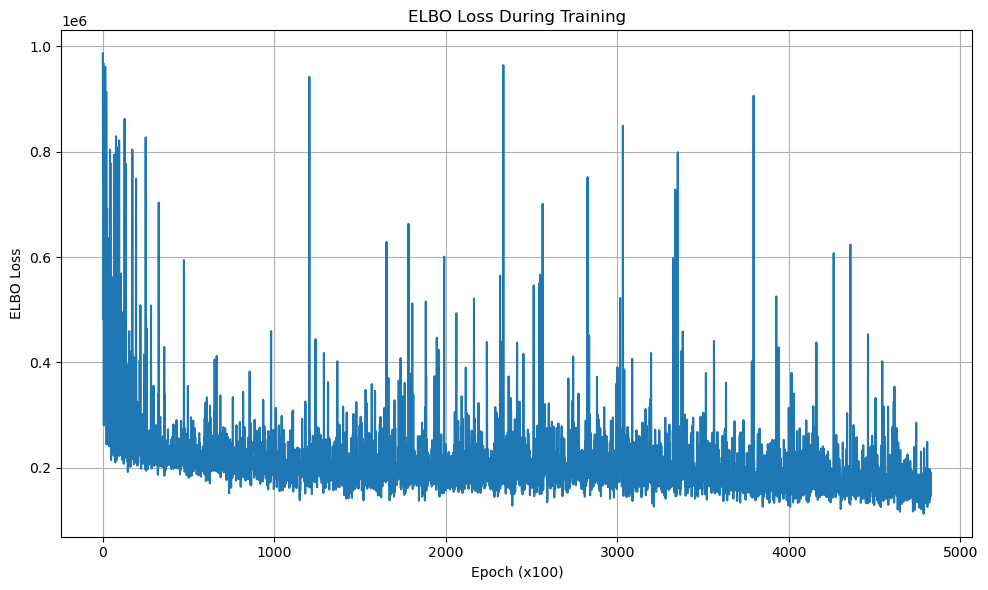

In [19]:
# Selection and test version + Log

# Set constants
num_samples = 50
num_iters = 5000
input_dim = 37
output_dim = 20
prior_scale = 20.
learning_rate = 0.001


# Reset model and optimizer
model = BNN(input_dim=input_dim).to(device)
guide = AutoMultivariateNormal(model, init_loc_fn=init_to_mean)
svi = SVI(model, guide, optim.Adam({"lr": learning_rate}), loss=Trace_ELBO(vectorize_particles=True))
pyro.clear_param_store()

losses = []

for i in tqdm(range(num_iters), desc=f"Training"):
    loss = svi.step(x_train_tensor, y_train_tensor.squeeze())
    if loss <= 1000000: losses.append(loss)
    if (i + 1) % 1000 == 0:
        print(loss)

result_rows = []
mse = 0

plt.figure(figsize=(10, 6))
plt.plot(range(0, len(losses)), losses)
plt.xlabel('Epoch (x100)')
plt.ylabel('ELBO Loss')
plt.title('ELBO Loss During Training')
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
import pickle
# Save the trained model and guide

# Save model and guide to files
model_path = f'../Result/251216_DateTest/trained_model_multiple_test{test_number}_re.pkl'
guide_path = f'../Result/251216_DateTest/trained_guide_multiple_test{test_number}_re.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(guide_path, 'wb') as f:
    pickle.dump(guide, f)

print(f"Model saved to {model_path}")
print(f"Guide saved to {guide_path}")

Model saved to ../Result/251216_DateTest/trained_model_multiple_test3_re.pkl
Guide saved to ../Result/251216_DateTest/trained_guide_multiple_test3_re.pkl


## Load model

Model loaded from trained_model2.pkl
Guide loaded from trained_guide2.pkl


 Validation:   0%|          | 0/6 [00:00<?, ?it/s]

태릉입구


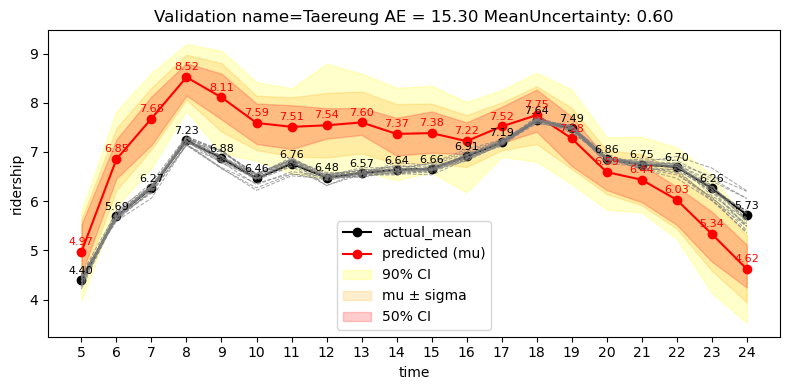

 Validation:  17%|█▋        | 1/6 [00:02<00:11,  2.28s/it]

상봉


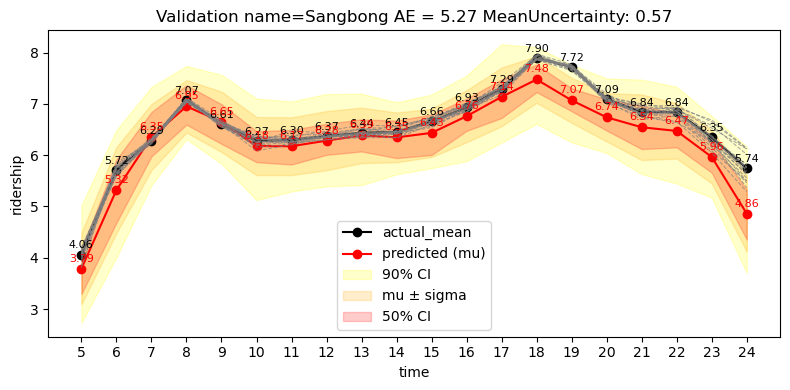

 Validation:  33%|███▎      | 2/6 [00:03<00:07,  1.91s/it]

상도


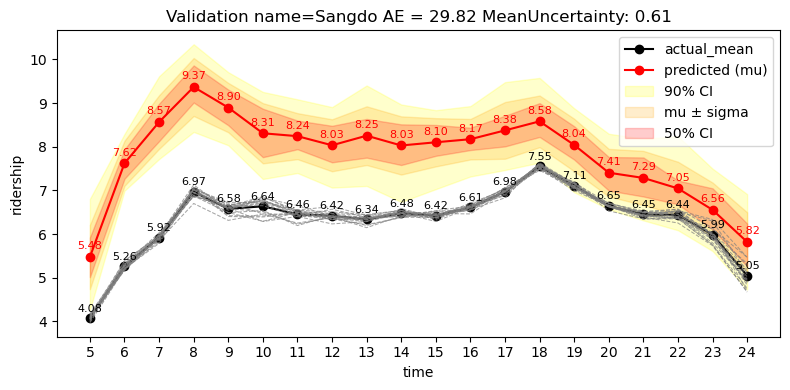

 Validation:  50%|█████     | 3/6 [00:05<00:05,  1.98s/it]

강남


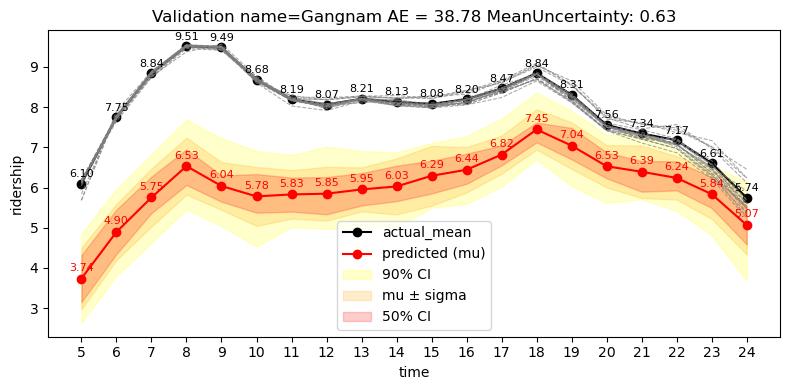

 Validation:  67%|██████▋   | 4/6 [00:08<00:04,  2.03s/it]

시청


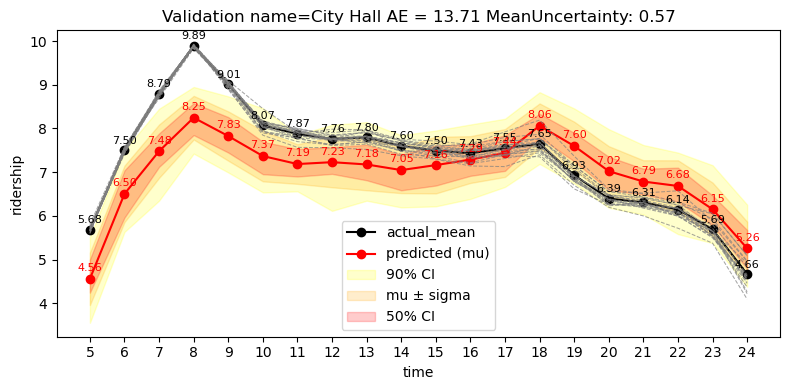

 Validation:  83%|████████▎ | 5/6 [00:11<00:02,  2.35s/it]

공덕


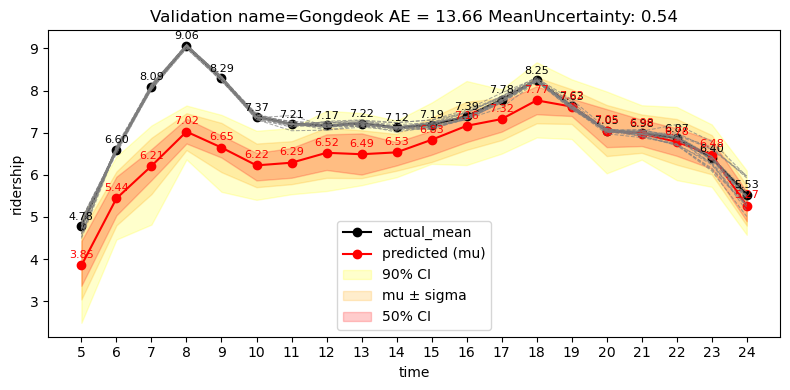

 Validation: 100%|██████████| 6/6 [00:14<00:00,  2.38s/it]

13.658330410990578


In [8]:
import pickle
#date_test = date_test2
# Load the trained model and guide
model_path = f'trained_model2.pkl'
guide_path = f'trained_guide2.pkl'

with open(model_path, 'rb') as f:
    model = pickle.load(f)

with open(guide_path, 'rb') as f:
    guide = pickle.load(f)

print(f"Model loaded from {model_path}")
print(f"Guide loaded from {guide_path}")

num_samples = 50
num_iters = 50000
input_dim = 37
output_dim = 20
prior_scale = 10.
learning_rate = 0.0005

total_mse = 0

for k, row in tqdm(enumerate(test_stations), total=len(val_input), desc=f" Validation"):
    print(row)
    mse = 0
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(val_input.iloc[k].values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)

    test_output_ids = df_date[(df_date['date'].isin(date_test)) & (df_date['name']==test_stations[k])].index
    test_output_df = df_y['ridership'].iloc[test_output_ids]
    ridership_val_arr = np.array(test_output_df)

    ridership_vals = np.array(test_output_df.mean()).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])

    result_list = []

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
        
    with torch.no_grad():
        preds = Predictive(model, guide=guide, num_samples=num_samples)(inputs_tensor)
        mus = preds['coefs'].mean(axis=0).numpy()
        sigmas = preds['coefs'].std(axis=0).numpy()
        
        # Calculate 50% confidence interval (25th to 75th percentile)
        mus_ci50_lower = np.percentile(preds['coefs'], 25, axis=0)
        mus_ci50_upper = np.percentile(preds['coefs'], 75, axis=0)
        
        # Calculate 90% confidence interval (5th to 95th percentile)
        mus_ci90_lower = np.percentile(preds['coefs'], 5, axis=0)
        mus_ci90_upper = np.percentile(preds['coefs'], 95, axis=0)

    ridership_flat = np.log(ridership_vals).flatten()

    # record results and update mse
    for t in range(len(mus)):
        mse += abs(float(mus[t]) - float(ridership_flat[t]))
        total_mse += mse

    # station name
    st_name = df_date.loc[test_output_ids[0]]['en_name']

    # plot actual (grey) vs predicted mu (red) with uncertainty band
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='black', marker='o', label='actual_mean')
    plt.plot(range(len(mus)), mus, color='red', marker='o', label='predicted (mu)')
    plt.fill_between(range(len(mus)), mus_ci90_lower, mus_ci90_upper, color='yellow', alpha=0.2, label='90% CI')
    plt.fill_between(range(len(mus)), mus - sigmas, mus + sigmas, color='orange', alpha=0.2, label='mu ± sigma')
    plt.fill_between(range(len(mus)), mus_ci50_lower, mus_ci50_upper, color='red', alpha=0.2, label='50% CI')
    
    for ridership_val in ridership_val_arr:
        plt.plot(range(len(ridership_flat)), np.log(ridership_val), color='gray', alpha = 0.7, linewidth = 0.75, linestyle = 'dashed')
    y_max = max(np.max(mus), np.max(ridership_flat))
    y_min = min(np.min(mus), np.min(ridership_flat))
    offset = (y_max - y_min) * 0.02 if y_max != y_min else 0.1
    plt.xticks(range(len(mus)), range(5, 25))

    for t in range(len(mus)):
        plt.text(t, float(ridership_flat[t]) + offset, f"{float(ridership_flat[t]):.2f}", color='black', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(mus[t]) + offset * 1.2, f"{float(mus[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
    plt.xlabel('time')
    plt.ylabel('ridership')
    plt.title(f'Validation name={st_name} AE = {mse:.2f} MeanUncertainty: {np.mean(sigmas):.2f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'../Result/251216_DateTest/Test{test_number}_Validation_{st_name}.png')
    plt.show()
    
    
print(mse)